# Telco Customer Churn — Deep EDA (ฉบับอธิบายละเอียด)

Notebook นี้วิเคราะห์ข้อมูลลูกค้าของบริษัทโทรคมนาคมแห่งหนึ่ง เพื่อหาว่า **ลูกค้าแบบไหนมีแนวโน้มเลิกใช้บริการ (Churn) มากกว่าคนอื่น**

**คำศัพท์ที่ต้องรู้ก่อนเริ่ม:**
- **Churn** = การที่ลูกค้ายกเลิกบริการ (ในข้อมูลนี้คือคอลัมน์ `Churn` ที่มีค่า "Yes" แปลว่ายกเลิก, "No" แปลว่ายังใช้อยู่)
- **EDA (Exploratory Data Analysis)** = การ "สำรวจข้อมูล" ก่อนสรุปผลอะไร คล้ายการพลิกดูตาราง Excel จากหลายมุม เพื่อดูว่าข้อมูลมีอะไรน่าสนใจ มีจุดผิดปกติตรงไหนบ้าง ก่อนที่จะฟันธงว่า "ปัจจัย A ทำให้คนเลิกใช้บริการ"
- **DataFrame** = คำที่ใช้เรียกตารางข้อมูลใน Python (ไลบรารีชื่อ `pandas`) ให้นึกภาพเหมือนชีท Excel 1 แผ่น มีแถว (rows) และคอลัมน์ (columns)

ในทุก step ด้านล่าง จะมี 3 ส่วนเสมอ: **(1) จะทำอะไร (2) โค้ด (3) ผลลัพธ์หมายความว่าอย่างไร** เพื่อให้ตามเข้าใจได้แม้ไม่มีพื้นฐานเขียนโปรแกรม


## Step 1: Data Loading & Structural Overview (โหลดข้อมูลและสำรวจโครงสร้างเบื้องต้น)

**จะทำอะไร:** เปิดไฟล์ข้อมูล (คล้ายการเปิดไฟล์ Excel) แล้วดูภาพรวมคร่าวๆ ก่อน เช่น
มีข้อมูลกี่แถว (กี่คน) กี่คอลัมน์ (กี่หัวข้อ), แต่ละคอลัมน์เก็บข้อมูลชนิดไหน (ตัวเลข หรือ ข้อความ),
และมีข้อมูลที่ "หายไป" (missing) หรือไม่

**ทำไมต้องทำก่อน:** เหมือนก่อนจะทำอาหาร ต้องดูก่อนว่าวัตถุดิบที่มีมีอะไรบ้าง สด/เสียไหม — ถ้าข้อมูลมีปัญหาแต่เราไม่รู้ตั้งแต่แรก
การวิเคราะห์ขั้นถัดไปจะผิดพลาดตามไปด้วย


In [1]:
# import แปลว่า "ดึงเครื่องมือมาใช้" -- pandas คือไลบรารี (ชุดเครื่องมือสำเร็จรูป) ยอดนิยมสำหรับจัดการตารางข้อมูลใน Python
import pandas as pd  # ตั้งชื่อย่อว่า pd เพื่อพิมพ์สั้นลง (เป็นธรรมเนียมที่ทุกคนใช้ตรงกัน)

# ปกติถ้าตารางมีคอลัมน์เยอะ pandas จะตัดบางคอลัมน์ไม่แสดง บรรทัดนี้สั่งให้แสดงครบทุกคอลัมน์เวลา print ตาราง
pd.set_option('display.max_columns', None)

# อ่านไฟล์ CSV (ไฟล์ตารางข้อมูลแบบข้อความ คั่นด้วยจุลภาค ",") เข้ามาเก็บในตัวแปรชื่อ df (ย่อจาก DataFrame)
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# df.shape คืนค่าเป็น (จำนวนแถว, จำนวนคอลัมน์) -- [0] คือดึงค่าแรก (แถว), [1] คือดึงค่าที่สอง (คอลัมน์)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 7043 rows x 21 columns


**ผลลัพธ์หมายความว่าอย่างไร:** ข้อมูลมี **7,043 แถว** (แปลว่ามีข้อมูลลูกค้า 7,043 คน) และ **21 คอลัมน์**
(แปลว่าลูกค้าแต่ละคนถูกบันทึกไว้ 21 หัวข้อ เช่น เพศ, ระยะเวลาที่เป็นลูกค้า, ค่าบริการรายเดือน ฯลฯ)


**จะทำอะไรต่อ:** ใช้คำสั่ง `.info()` เพื่อดูว่าแต่ละคอลัมน์เก็บข้อมูล "ชนิด" ไหน

**ทำไมต้องรู้ชนิดข้อมูล:** เพราะโปรแกรมจะคำนวณผิดถ้าเข้าใจชนิดข้อมูลผิด — เช่นถ้าคอลัมน์ตัวเลขถูกเก็บเป็น "ข้อความ" (string/text)
เราจะเอามันมาบวก/ลบ/หาค่าเฉลี่ยไม่ได้เลย ต้องแปลงก่อน


In [2]:
# .info() คือคำสั่งสรุปภาพรวมของตาราง: มีกี่คอลัมน์, แต่ละคอลัมน์มีข้อมูลกี่แถวที่ "ไม่ว่าง" (non-null), และเก็บเป็นชนิดข้อมูล (Dtype) อะไร
# Dtype ที่จะเจอบ่อย: int64 = จำนวนเต็ม, float64 = ทศนิยม, object = ข้อความ (string)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**ผลลัพธ์หมายความว่าอย่างไร (จุดสำคัญ 2 จุด):**

1. คอลัมน์ `SeniorCitizen` เป็นชนิด `int64` (ตัวเลข 0 กับ 1) ในขณะที่คอลัมน์อื่นที่ควรมีความหมายคล้ายกัน เช่น `Partner`, `Dependents`
   เก็บเป็นข้อความ "Yes"/"No" — ไม่ตรงรูปแบบกัน ทำให้ตอนทำกราฟเทียบกันทีหลังจะดูไม่เข้าชุด ต้องแก้ให้เหมือนกัน

2. **คอลัมน์ `TotalCharges` (ค่าใช้จ่ายรวมทั้งหมดของลูกค้าคนนั้น) ถูกเก็บเป็น `object` (ข้อความ) ทั้งที่ควรเป็นตัวเลข**
   นี่คือสัญญาณเตือนว่ามีบางแถวในคอลัมน์นี้พิมพ์เป็นตัวเลขไม่ได้ (เดี๋ยวจะไปตรวจดูใน Step 2 ว่าทำไม)


**จะทำอะไรต่อ:** ใช้คำสั่ง `.head()` เพื่อขอดูข้อมูลจริง 5 แถวแรก (เหมือนเปิดดู 5 บรรทัดแรกของ Excel)
เพื่อให้เห็นภาพว่าข้อมูลแต่ละคอลัมน์หน้าตาเป็นอย่างไรจริงๆ ไม่ใช่แค่ดูสรุปเฉยๆ


In [3]:
# .head() แปลว่า "ขอดูส่วนหัว" -- ค่าเริ่มต้นคือ 5 แถวแรกของตาราง (ใส่ตัวเลขในวงเล็บได้ เช่น .head(10) เพื่อดู 10 แถว)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**ผลลัพธ์หมายความว่าอย่างไร:** เห็นตัวอย่างข้อมูลลูกค้าจริง 5 คน เช่น ลูกค้าคนแรกเป็นผู้หญิง เป็นลูกค้ามาแล้ว 1 เดือน (`tenure`=1)
จ่ายค่าบริการ 29.85 ต่อเดือน และยังไม่ยกเลิกบริการ (`Churn`="No")

สังเกตคอลัมน์ `MultipleLines` ของลูกค้าคนแรก มีค่าเป็น **"No phone service"** ไม่ใช่แค่ "No" เฉยๆ — เพราะลูกค้าคนนี้ไม่มีบริการโทรศัพท์เลย
จึงตอบคำถาม "มีสายโทรศัพท์หลายเลขไหม" ไม่ได้ตั้งแต่ต้น เป็นรายละเอียดเล็กๆ ที่ต้องจำไว้ตอนวิเคราะห์ทีหลัง


**จะทำอะไรต่อ:** เช็คว่ามีข้อมูล "หายไป" (missing values) ตรงไหนบ้างในตาราง

**Missing value คืออะไร:** คือช่องที่ควรมีข้อมูลแต่ดันว่างเปล่า เช่น ถ้าลืมกรอกอายุของคนหนึ่งในแบบสอบถาม ช่องนั้นจะเป็น missing
ถ้าไม่เช็คก่อน การคำนวณค่าเฉลี่ย/กราฟทีหลังอาจผิดเพี้ยนโดยไม่รู้ตัว


In [4]:
# .isnull() เช็คทีละช่องว่า "ว่างจริงๆ ไหม" (ได้ค่า True/False) แล้ว .sum() นับจำนวน True (ช่องที่ว่าง) ในแต่ละคอลัมน์
print("Missing values per column (as seen by pandas):")
df.isnull().sum()

Missing values per column (as seen by pandas):


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**ผลลัพธ์หมายความว่าอย่างไร (จุดที่ต้องระวังมาก):** ทุกคอลัมน์ขึ้น **0** หมายความว่า pandas "มองว่า" ไม่มีข้อมูลหายไปเลย

แต่นี่คือกับดัก! จำได้ไหมว่า Step ก่อนหน้าเราเจอว่า `TotalCharges` ถูกเก็บเป็นข้อความ (object) ทั้งที่ควรเป็นตัวเลข —
เป็นไปได้ว่าบางแถวในคอลัมน์นี้ไม่ได้เป็น "ว่างเปล่าแบบที่ pandas รู้จัก" แต่เป็น **ช่องว่าง (spacebar) ที่ถูกพิมพ์ไว้** ซึ่งหน้าตาเหมือนมีข้อความอยู่
pandas เลยไม่นับว่ามันหายไป ทั้งที่จริงๆ แล้วมันใช้งานไม่ได้เลย เราจะไปเจาะดูและแก้ไขเรื่องนี้ใน Step 2


## Step 2: Data Cleaning & Type Correction (ทำความสะอาดข้อมูล)

**จะทำอะไร:** แก้ปัญหา 3 จุดที่เจอใน Step 1:
1. คอลัมน์ `TotalCharges` มีค่าที่ไม่ใช่ตัวเลขจริงซ่อนอยู่ ต้องหาให้เจอและตัดสินใจว่าจะทำอย่างไร
2. คอลัมน์ `SeniorCitizen` เก็บเป็น 0/1 ไม่ตรงรูปแบบกับคอลัมน์อื่น ต้องแปลงให้เหมือนกัน
3. คอลัมน์ `customerID` เป็นแค่ "รหัสประจำตัว" ของลูกค้า ไม่ใช่ข้อมูลที่ใช้วิเคราะห์ ต้องแยกออกมาต่างหาก

**ทำไมต้องทำก่อนวิเคราะห์ต่อ:** หลักการสำคัญของ data science คือ "Garbage in, garbage out" — ถ้าข้อมูลตั้งต้นสกปรก/ผิดรูปแบบ
ผลการวิเคราะห์ที่ได้ก็จะผิดตามไปด้วย แม้จะใช้เทคนิคสถิติที่ถูกต้องก็ตาม


**จะทำอะไร:** สั่งให้ pandas "บังคับแปลง" คอลัมน์ `TotalCharges` เป็นตัวเลขจริงๆ
ถ้าช่องไหนแปลงเป็นตัวเลขไม่ได้ (เช่นเป็นช่องว่าง) จะถูกเปลี่ยนเป็นสัญลักษณ์พิเศษที่ชื่อว่า **NaN** (ย่อจาก "Not a Number" แปลว่า "ไม่ใช่ตัวเลข/ไม่มีค่า")
ซึ่ง pandas จะรู้จักและนับเป็น missing value ได้อย่างถูกต้องแล้ว (ต่างจาก Step 1 ที่มันมองไม่เห็น)


In [5]:
# pd.to_numeric(...) = สั่งแปลงคอลัมน์นี้เป็นตัวเลข
# errors='coerce' = ถ้าเจอค่าที่แปลงเป็นตัวเลขไม่ได้ ให้ใส่ NaN แทน (ไม่ต้อง error/หยุดโปรแกรม)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Number of NaN in TotalCharges:", df['TotalCharges'].isnull().sum())

# กรองดูเฉพาะแถวที่ TotalCharges กลายเป็น NaN เพื่อดูว่าลูกค้ากลุ่มนี้หน้าตาเป็นอย่างไร
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of NaN in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**ผลลัพธ์หมายความว่าอย่างไร:** เจอ **11 แถว** ที่ `TotalCharges` แปลงเป็นตัวเลขไม่ได้ (ค่าที่แท้จริงคือช่องว่างที่แอบพิมพ์ไว้ในไฟล์ต้นฉบับ)
สังเกตว่าทั้ง 11 คนนี้ยังมี `MonthlyCharges` (ค่าบริการต่อเดือน) เป็นตัวเลขปกติ มีแค่ `TotalCharges` (ยอดรวมสะสม) เท่านั้นที่หาย


**จะทำอะไร:** ก่อนจะตัดสินใจลบข้อมูล 11 แถวนี้ทิ้ง ต้อง "สืบสวน" ก่อนว่าทำไมมันถึงว่าง — ห้ามลบทิ้งมั่วๆ โดยไม่รู้สาเหตุ
เพราะถ้าสาเหตุจริงๆ เกี่ยวข้องกับ Churn (เช่น คนที่ยกเลิกไวมากๆ ระบบไม่ทันบันทึกยอดเงิน) การลบทิ้งจะทำให้ผลวิเคราะห์เอนเอียงผิดเพี้ยน

วิธีตรวจสอบ: ดูว่าคอลัมน์ `tenure` (จำนวนเดือนที่เป็นลูกค้ามาแล้ว) ของ 11 คนนี้เป็นเท่าไหร่


In [6]:
print("Unique tenure values for rows with missing TotalCharges:",
      df[df['TotalCharges'].isnull()]['tenure'].unique())  # .unique() = แสดงค่าที่ไม่ซ้ำกันทั้งหมดที่เจอ

# ก่อนลบ เก็บจำนวนแถวเดิมไว้เทียบ
before = df.shape[0]

# คัดเอาเฉพาะแถวที่ TotalCharges "ไม่ใช่" NaN (.notnull()) เก็บทับตัวแปร df เดิม = คือการตัดแถวที่มีปัญหาทิ้งไป
# .reset_index(drop=True) = เรียงเลขลำดับแถวใหม่ตั้งแต่ 0 ใหม่ (เพราะแถวเดิมบางเลขถูกลบไปแล้วจะมีช่องว่างของเลขลำดับ)
df = df[df['TotalCharges'].notnull()].reset_index(drop=True)
after = df.shape[0]

print(f"Dropped {before - after} rows with missing TotalCharges (tenure=0, brand-new customers).")
print(f"Remaining rows: {after}")

Unique tenure values for rows with missing TotalCharges: [0]
Dropped 11 rows with missing TotalCharges (tenure=0, brand-new customers).
Remaining rows: 7032


**ผลลัพธ์หมายความว่าอย่างไร:** พบว่าทั้ง 11 คนนี้มีค่า `tenure` เป็น **0 เดือน** เหมือนกันหมด — แปลว่าเป็น **ลูกค้าที่เพิ่งสมัครใหม่**
ยังไม่ครบ 1 เดือนแรกที่จะถูกเรียกเก็บบิล จึงยังไม่มี "ยอดรวมสะสม" ให้บันทึก (ไม่ใช่ข้อมูลผิดพลาดแบบสุ่ม)

เพราะเหตุผลนี้ชัดเจนและไม่เกี่ยวกับพฤติกรรม Churn โดยตรง เราจึง **ตัดสินใจลบ 11 แถวนี้ทิ้ง** อย่างมั่นใจ เหลือข้อมูล **7,032 แถว** ให้วิเคราะห์ต่อ


**จะทำอะไร:** แปลงคอลัมน์ `SeniorCitizen` จากตัวเลข 0/1 ให้เป็นข้อความ "No"/"Yes" แทน
เพื่อให้หน้าตาเหมือนกับคอลัมน์อื่นๆ ที่เป็นคำถามใช่/ไม่ใช่ (เช่น `Partner`, `Dependents`)


In [7]:
# .map({0: 'No', 1: 'Yes'}) = กติกาการแปลงค่า: เจอเลข 0 ให้เปลี่ยนเป็นคำว่า "No", เจอเลข 1 ให้เปลี่ยนเป็นคำว่า "Yes"
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# .value_counts() = นับว่าแต่ละค่าที่ปรากฏในคอลัมน์นี้มีกี่แถว
df['SeniorCitizen'].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

**ผลลัพธ์หมายความว่าอย่างไร:** ยืนยันว่าแปลงสำเร็จ — มีลูกค้าที่ไม่ใช่ผู้สูงอายุ (`No`) 5,890 คน และเป็นผู้สูงอายุ (`Yes`) 1,142 คน
(จำนวนคนเท่าเดิม แค่เปลี่ยนป้ายกำกับให้อ่านง่ายขึ้นและเข้าชุดกับคอลัมน์อื่น)


**จะทำอะไร:** ตั้งให้คอลัมน์ `customerID` (รหัสลูกค้า เช่น "7590-VHVEG") เป็น **index** ของตาราง

**Index คืออะไร:** เปรียบเหมือน "เลขที่แถว" หรือ "ป้ายชื่อ" ประจำแต่ละแถว ปกติ pandas จะใส่เลข 0,1,2,... ให้อัตโนมัติ
แต่ในที่นี้เราอยากใช้รหัสลูกค้าที่มีความหมายแทน เพื่อให้ระบุตัวลูกค้าแต่ละแถวได้ง่ายขึ้น และไม่เอา `customerID` (ซึ่งเป็นแค่รหัส ไม่ใช่ข้อมูลลักษณะลูกค้า)
ไปปนกับคอลัมน์ที่จะใช้วิเคราะห์จริงๆ


In [8]:
df = df.set_index('customerID')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**ผลลัพธ์หมายความว่าอย่างไร:** ตอนนี้รหัสลูกค้าอยู่ทางซ้ายสุดของตารางในฐานะ "ชื่อแถว" แทนที่จะเป็นแค่คอลัมน์ธรรมดา
ทำให้ตารางเหลือ 20 คอลัมน์สำหรับใช้วิเคราะห์ (ไม่นับ customerID)


**จะทำอะไร:** เรียก `.info()` อีกครั้งเพื่อ "เช็คสรุปท้าย Step" ว่าทุกอย่างที่ตั้งใจแก้ไข ถูกต้องครบแล้วจริงหรือไม่ ก่อนไปขั้นตอนถัดไป


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null 

**ผลลัพธ์หมายความว่าอย่างไร (สรุป Step 2):** ตอนนี้ข้อมูลสะอาดพร้อมวิเคราะห์แล้ว —

- เหลือ **7,032 แถว, 20 คอลัมน์** (ไม่รวม customerID ที่ย้ายไปเป็น index แล้ว)
- `TotalCharges` เป็นชนิด `float64` (ตัวเลขทศนิยม) แล้ว ไม่ใช่ข้อความอีกต่อไป
- `SeniorCitizen` เป็นข้อความ "Yes"/"No" ตรงรูปแบบกับคอลัมน์อื่นแล้ว
- ทุกคอลัมน์มีข้อมูลครบ 7,032 แถว ไม่มีช่องว่างเหลือ (non-null ครบทุกคอลัมน์)

ขั้นตอนถัดไป (Step 3 เป็นต้นไป) จะเริ่มดูว่าปัจจัยไหนสัมพันธ์กับการเลิกใช้บริการ (Churn) จริงๆ


## Step 3: Univariate Analysis — Target Variable (สำรวจตัวแปรเป้าหมาย)

**จะทำอะไร:** ดูว่าในลูกค้าทั้งหมด 7,032 คน มีกี่คนที่ "ยกเลิกบริการ" (Churn) กี่คนที่ "ยังใช้อยู่" ทั้งในรูปจำนวนคนและสัดส่วน %

**ทำไมต้องทำก่อนเรื่องอื่น:** ตัวเลขนี้เรียกว่า **base rate** (อัตราพื้นฐาน) ของ churn — ในขั้นตอนถัดไปเราจะแบ่งลูกค้าเป็นกลุ่มย่อยๆ
(เช่น กลุ่มที่ทำสัญญารายเดือน vs กลุ่มที่ทำสัญญา 2 ปี) แล้วดูว่ากลุ่มไหน churn เยอะกว่ากัน — คำว่า "เยอะกว่า" ต้องเทียบกับ base rate นี้เสมอ
ถ้าไม่รู้ base rate ก่อน จะไม่มีจุดอ้างอิงว่าตัวเลขที่เจอทีหลัง "สูงผิดปกติ" จริงหรือไม่


In [10]:
# import เครื่องมือสำหรับวาดกราฟ
# matplotlib.pyplot คือไลบรารีวาดกราฟพื้นฐานของ Python, seaborn คือไลบรารีต่อยอดที่ทำให้กราฟสวยขึ้นและใช้งานง่ายขึ้น
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าหน้าตากราฟให้ดูสะอาดตา (เป็นธีมสำเร็จรูปของ seaborn)
sns.set_style('whitegrid')

# ตั้งค่าฟอนต์ให้รองรับภาษาไทยในกราฟ (ฟอนต์ default ของ matplotlib ไม่มีตัวอักษรไทย ทำให้ขึ้นเป็นกล่องว่างๆ)
plt.rcParams['font.family'] = 'Tahoma'

# .value_counts() นับจำนวนแถวของแต่ละค่าที่ปรากฏในคอลัมน์ Churn (นับว่ามี "Yes" กี่แถว, "No" กี่แถว)
churn_counts = df['Churn'].value_counts()

# normalize=True สั่งให้ .value_counts() คืนค่าเป็น "สัดส่วน" (0.0-1.0) แทนที่จะเป็นจำนวนนับดิบๆ
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("จำนวนลูกค้าแยกตาม Churn:")
print(churn_counts)
print()
print("สัดส่วน % แยกตาม Churn:")
print(churn_pct.round(2))

จำนวนลูกค้าแยกตาม Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

สัดส่วน % แยกตาม Churn:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


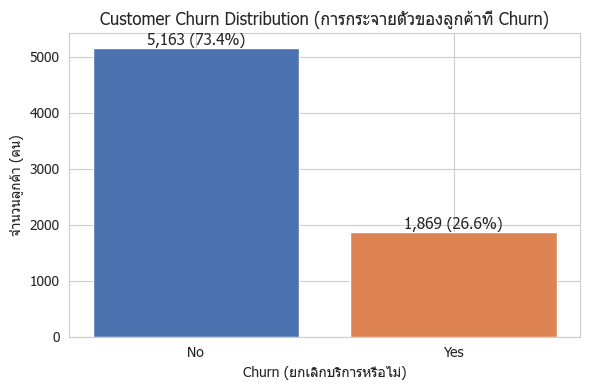

In [11]:
# สร้างพื้นที่วาดกราฟขนาด 6x4 นิ้ว
fig, ax = plt.subplots(figsize=(6, 4))

# วาด bar chart จากตัวเลขที่นับไว้ข้างบน
bars = ax.bar(churn_counts.index, churn_counts.values, color=['#4C72B0', '#DD8452'])

# ใส่ label ตัวเลขและ % ไว้เหนือแต่ละแท่ง เพื่อให้อ่านค่าได้ทันทีโดยไม่ต้องกะประมาณจากความสูงแท่ง
for bar, pct in zip(bars, churn_pct[churn_counts.index]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:,} ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Customer Churn Distribution (การกระจายตัวของลูกค้าที่ Churn)')
ax.set_xlabel('Churn (ยกเลิกบริการหรือไม่)')
ax.set_ylabel('จำนวนลูกค้า (คน)')
plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร:**

- ลูกค้าที่ **ยังไม่ยกเลิกบริการ (No)** มี **5,163 คน (73.4%)**
- ลูกค้าที่ **ยกเลิกบริการไปแล้ว (Yes)** มี **1,869 คน (26.6%)**

ตัวเลข **26.6% นี้คือ base rate ของ churn** ที่จะใช้อ้างอิงตลอดการวิเคราะห์ที่เหลือ ตัวอย่างการนำไปใช้:
ถ้า Step ถัดไปเจอว่ากลุ่มลูกค้าสัญญารายเดือน (Month-to-month) มี churn rate 40% แปลว่าเสี่ยงกว่าค่าเฉลี่ยทั้งบริษัทเกือบ 1.5 เท่า
แต่ถ้าเจอกลุ่มที่ churn rate 28% แปลว่าใกล้เคียงค่าเฉลี่ย ไม่ถือเป็นกลุ่มเสี่ยงพิเศษ

**ข้อสังเกตเพิ่มเติม:** ข้อมูลชุดนี้ถือว่า "ไม่สมดุล" (imbalanced) พอสมควร คือกลุ่ม No มีมากกว่ากลุ่ม Yes เกือบ 3 เท่า
ประเด็นนี้สำคัญมากตอนทำ Machine Learning ใน Step 12-13 ข้างหน้า (ต้องใช้ SMOTE แก้ปัญหานี้) แต่สำหรับ EDA ตอนนี้แค่ต้องระวังว่า
เวลาเทียบกลุ่มย่อยต้องดู "สัดส่วน %" เป็นหลัก ไม่ใช่ดู "จำนวนคน" ดิบๆ เพราะกลุ่มที่มีคนเยอะกว่าจะมีจำนวนคน churn ดิบๆ สูงกว่าอยู่แล้วโดยธรรมชาติ


## Step 4: Univariate Analysis — All Features (สำรวจการกระจายตัวของทุกตัวแปร)

**จะทำอะไร:** ดูการกระจายตัว (distribution) ของทุกคอลัมน์ในตาราง ทีละคอลัมน์ ก่อนที่จะเริ่มเปรียบเทียบกับ Churn ใน Step ถัดไป —
แบ่งเป็น 2 กลุ่มตามชนิดข้อมูล:
1. **ตัวแปรหมวดหมู่ (categorical)** เช่น `gender`, `Contract`, `InternetService` — ดูด้วย countplot/สัดส่วน %
2. **ตัวแปรตัวเลขต่อเนื่อง (numeric)** เช่น `tenure`, `MonthlyCharges`, `TotalCharges` — ดูด้วย histogram/boxplot/`describe()`

**ทำไมต้องทำก่อนเทียบกับ Churn:** เหมือนก่อนจะถามว่า "ปัจจัย A เกี่ยวกับ Churn ไหม" ต้องรู้ก่อนว่าปัจจัย A เองมีหน้าตาเป็นอย่างไร
เช่น ถ้าคอลัมน์หนึ่งมีแค่ค่าเดียวเกือบทั้งหมด (เช่น 99% เป็น "No") การเทียบกับ Churn ทีหลังจะไม่มีความหมายทางสถิติมากนัก
เพราะกลุ่มเปรียบเทียบอีกฝั่งมีตัวอย่างน้อยเกินไป การรู้การกระจายตัวล่วงหน้าจะช่วยให้ตีความผลใน Step 5-6 ได้ถูกต้องและระวังจุดที่ต้องระวังไว้ก่อน

### 4.1 ตัวแปรหมวดหมู่ (Categorical Features)

**จะทำอะไร:** แยกรายชื่อคอลัมน์ที่เป็นหมวดหมู่ออกจากคอลัมน์ตัวเลข แล้ววาด bar chart แสดงสัดส่วน % ของแต่ละหมวดหมู่ ทีละคอลัมน์ รวมทั้งหมด 16 คอลัมน์
(ไม่รวม `Churn` เพราะสำรวจไปแล้วใน Step 3 และไม่รวม `tenure`/`MonthlyCharges`/`TotalCharges` เพราะเป็นตัวเลขต่อเนื่อง จะไปดูแยกในหัวข้อ 4.2)

In [12]:
# แยกรายชื่อคอลัมน์ประเภทหมวดหมู่ (categorical) ออกจากคอลัมน์ประเภทตัวเลขต่อเนื่อง (numeric)
# อ้างอิงตาม column groups ใน README: Demographics + Account info (ยกเว้นตัวเลข) + Services
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                     'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# numeric_cols เก็บคอลัมน์ตัวเลขต่อเนื่อง 3 ตัว ที่จะไปดูแยกในหัวข้อ 4.2
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f"จำนวนคอลัมน์ประเภทหมวดหมู่ (categorical): {len(categorical_cols)}")
print(f"จำนวนคอลัมน์ตัวเลข (numeric): {len(numeric_cols)}")

จำนวนคอลัมน์ประเภทหมวดหมู่ (categorical): 16
จำนวนคอลัมน์ตัวเลข (numeric): 3


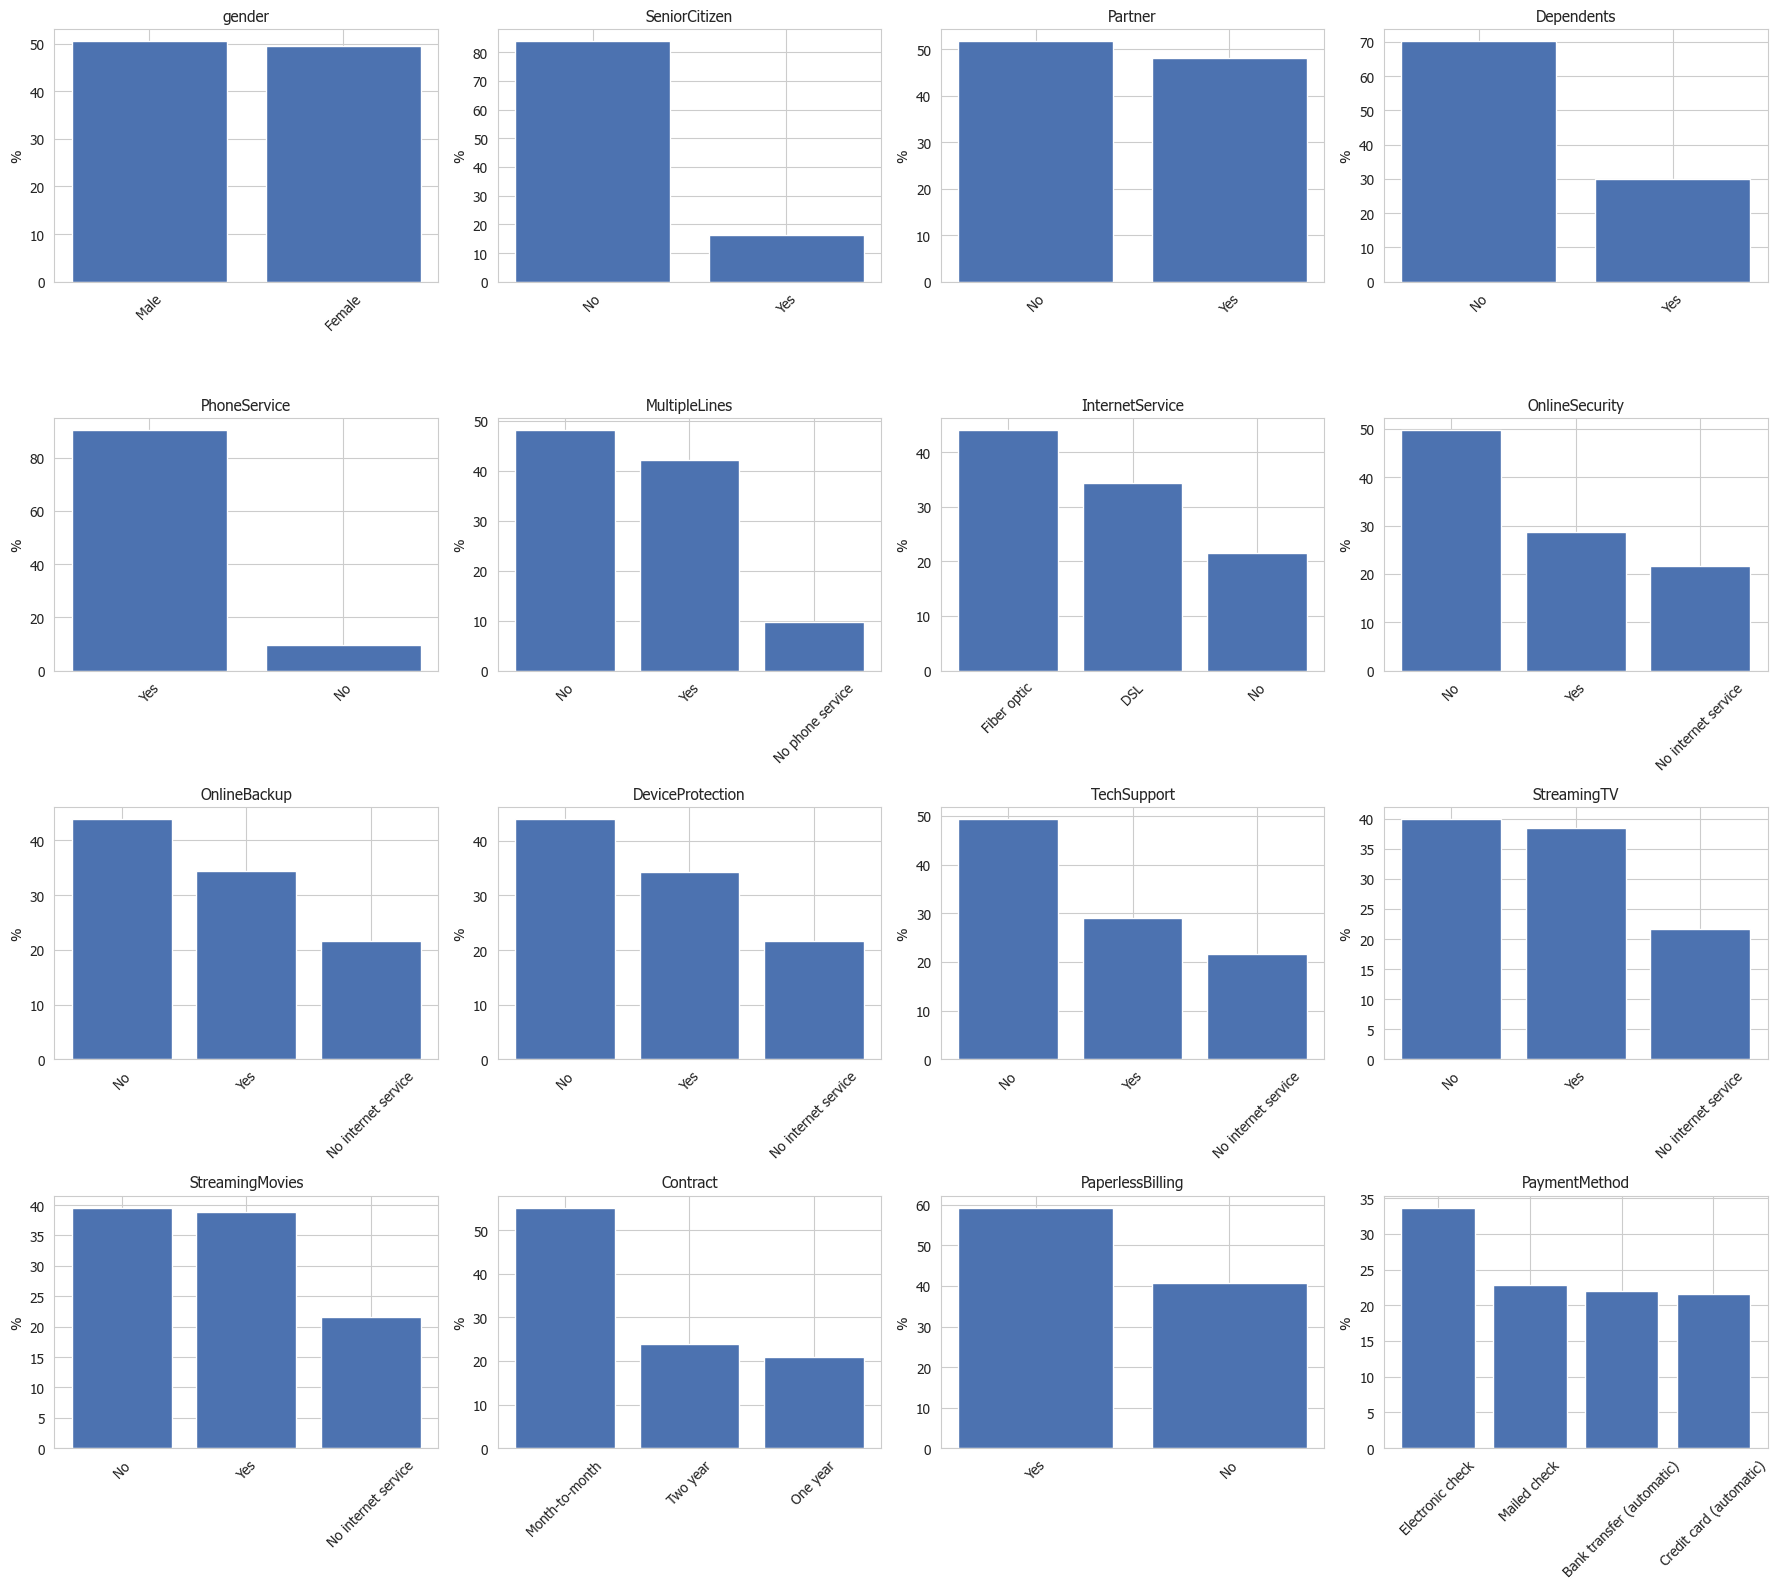

In [13]:
# สร้าง grid ของกราฟ 4 แถว x 4 คอลัมน์ (รองรับ 16 คอลัมน์ categorical ได้พอดี) ขนาดรวม 18x16 นิ้ว
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()  # .flatten() แปลง array 2 มิติ (4x4) ให้เป็น array 1 มิติยาว 16 ช่อง เพื่อวนลูปทีละช่องได้ง่ายๆ

# วนลูปทีละคอลัมน์ categorical พร้อมดึง index (i) มาด้วย เพื่อรู้ว่าจะวาดกราฟลงช่องไหนใน grid
for i, col in enumerate(categorical_cols):
    # นับสัดส่วน % ของแต่ละหมวดหมู่ในคอลัมน์นี้ (normalize=True คืนสัดส่วน 0.0-1.0 แล้วคูณ 100 ให้เป็น %)
    counts = df[col].value_counts(normalize=True) * 100
    axes[i].bar(counts.index, counts.values, color='#4C72B0')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=45)  # หมุน label แกน x 45 องศา กันตัวหนังสือทับกันตอนชื่อหมวดหมู่ยาว (เช่น PaymentMethod)

plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร (ประเด็นสำคัญจากกราฟทั้ง 16 คอลัมน์):**

- **สมดุลใกล้เคียง 50/50:** `gender` (ชาย/หญิงพอๆ กัน), `Partner`, `PaperlessBilling` — ตัวแปรกลุ่มนี้ไม่เอนไปทางใดทางหนึ่งมาก
- **เอียงไปทาง "No" ชัดเจน:** `SeniorCitizen` (ส่วนใหญ่ไม่ใช่ผู้สูงอายุ), `Dependents`, และบริการเสริมทั้งหมด (`OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) — ลูกค้าส่วนใหญ่ไม่ได้สมัครบริการเสริมเหล่านี้
- **เอียงไปทาง "Yes" ชัดเจน:** `PhoneService` (เกือบทุกคนมีบริการโทรศัพท์)
- **`Contract`:** ลูกค้าส่วนใหญ่เป็นสัญญารายเดือน (Month-to-month) มากกว่าสัญญาระยะยาว (1 year, 2 year) — น่าสนใจเพราะสัญญารายเดือนมักผูกกับความเสี่ยง churn สูงกว่า (ต้องเช็คใน Step 5)
- **`InternetService`:** แบ่งเป็น 3 กลุ่ม (DSL, Fiber optic, No) ไม่ใช่ 2 กลุ่มเหมือนตัวแปร Yes/No ทั่วไป — ต้องระวังตอนตีความ crosstab ใน Step 5
- **`PaymentMethod`:** มี 4 วิธีชำระเงิน กระจายไม่เท่ากัน โดย "Electronic check" ดูจะมีสัดส่วนสูงกว่ากลุ่มอื่นเล็กน้อย

ข้อสังเกตสำคัญ: หลายคอลัมน์บริการเสริม (OnlineSecurity ฯลฯ) ที่ดูเหมือนเอียงไปทาง "No" มาก แท้จริงแล้วบางส่วนเป็นค่า "No internet service"
(ลูกค้าที่ไม่ได้สมัครอินเทอร์เน็ตเลย จึงตอบคำถามเรื่องบริการเสริมอินเทอร์เน็ตไม่ได้ตั้งแต่ต้น) ไม่ใช่ "No" แบบเลือกปฏิเสธบริการล้วนๆ
เป็นรายละเอียดที่ต้องแยกให้ออกตอนตีความ crosstab ใน Step 5

### 4.2 ตัวแปรตัวเลขต่อเนื่อง (Numeric Features)

**จะทำอะไร:** ดูสถิติเชิงพรรณนา (`describe()`) และรูปร่างการกระจายตัว (histogram) พร้อม outlier (boxplot) ของตัวเลข 3 ตัว: `tenure`
(จำนวนเดือนที่เป็นลูกค้า), `MonthlyCharges` (ค่าบริการต่อเดือน), `TotalCharges` (ค่าใช้จ่ายสะสมทั้งหมด)

**ทำไมต้องทำ:** ตัวเลขอย่าง mean/median/ค่าผิดปกติ (outlier) จะช่วยตัดสินใจได้ว่าตอนเปรียบเทียบกับ Churn ใน Step 6 ควรใช้สถิติแบบไหน
(เช่นถ้าข้อมูลเบ้มาก ค่าเฉลี่ยจะถูกดึงผิดเพี้ยนได้ง่าย ต้องดู median ประกอบด้วย)

In [14]:
# .describe() สรุปสถิติเชิงพรรณนาของคอลัมน์ตัวเลขทั้ง 3 ตัว: จำนวนแถว (count), ค่าเฉลี่ย (mean),
# ส่วนเบี่ยงเบนมาตรฐาน (std แปลว่าข้อมูลกระจายจากค่าเฉลี่ยมากน้อยแค่ไหน), ค่าต่ำสุด/สูงสุด (min/max)
# และควอร์ไทล์ (25%, 50%=median คือค่ากึ่งกลาง, 75%)
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


**ผลลัพธ์หมายความว่าอย่างไร:**

- **`tenure`:** เฉลี่ยประมาณ 32 เดือน (2.7 ปี) ต่ำสุด 1 เดือน สูงสุด 72 เดือน (6 ปี) — median อยู่ที่ 29 เดือน ใกล้เคียงกับ mean
  แปลว่าไม่เบ้มาก แต่ช่วง (range) กว้างมาก แปลว่ามีทั้งลูกค้าใหม่และลูกค้าเก่าคละกันเยอะ
- **`MonthlyCharges`:** เฉลี่ยประมาณ 65 บาท/เดือน (หน่วยในไฟล์ต้นฉบับ) ต่ำสุด ~18 สูงสุด ~119 — กระจายค่อนข้างกว้างเช่นกัน
- **`TotalCharges`:** เฉลี่ยประมาณ 2,283 ค่ามัธยฐาน (median) ต่ำกว่าค่าเฉลี่ยพอสมควร (~1,397) ซึ่งเป็นสัญญาณว่าข้อมูลนี้ **เบ้ขวา (right-skewed)**
  — มีลูกค้าจำนวนหนึ่งที่จ่ายสะสมสูงมาก (ลูกค้าอยู่นาน) ดึงค่าเฉลี่ยให้สูงกว่าค่ากลางทั่วไป ต้องระวังใช้ median ประกอบเวลาสรุปผลใน Step 6

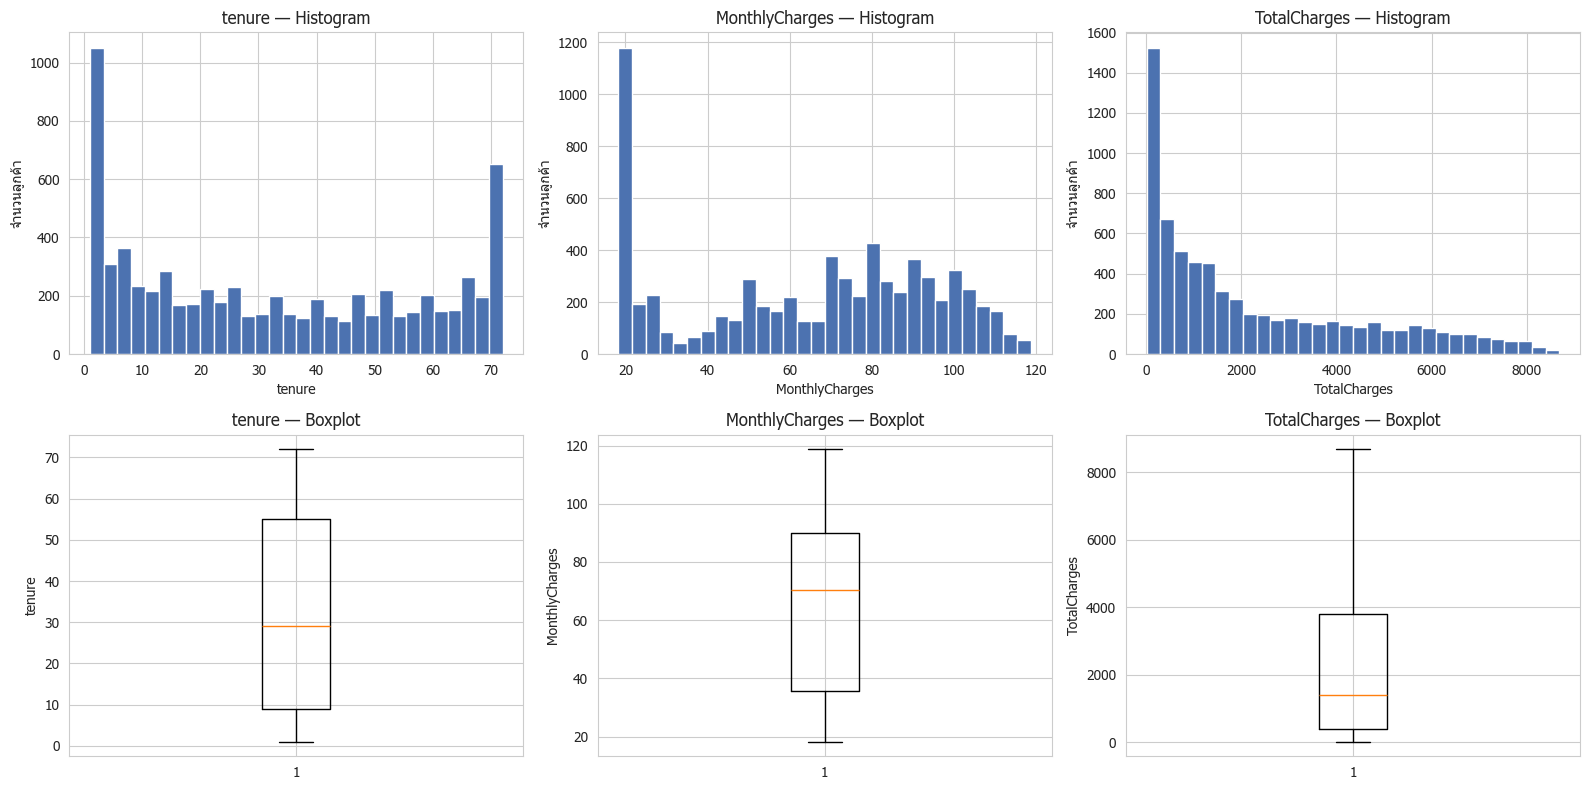

In [15]:
# สร้าง grid กราฟ 2 แถว x 3 คอลัมน์: แถวบนเป็น histogram, แถวล่างเป็น boxplot ของตัวเลข 3 ตัว
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(numeric_cols):
    # แถวบน (index แถว 0): histogram ดูรูปร่างการกระจายตัวของข้อมูล (bins=30 คือแบ่งข้อมูลเป็น 30 ช่วงเพื่อนับความถี่)
    axes[0, i].hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[0, i].set_title(f'{col} — Histogram')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('จำนวนลูกค้า')

    # แถวล่าง (index แถว 1): boxplot แสดง median (เส้นกลางกล่อง), IQR (ตัวกล่อง = ช่วง 25%-75%),
    # และ outlier (จุดที่อยู่นอกหนวด ถ้ามี) เพื่อเช็คว่ามีค่าผิดปกติสุดขั้วหรือไม่
    axes[1, i].boxplot(df[col], vert=True)
    axes[1, i].set_title(f'{col} — Boxplot')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

**ผลลัพธ์หมายความว่าอย่างไร:**

- **`tenure`:** histogram มีลักษณะเป็น "รูปตัว U" คร่าวๆ — ลูกค้าจำนวนมากอยู่ในช่วงเพิ่งเริ่มต้น (1-5 เดือน) และอีกกลุ่มใหญ่อยู่ช่วงปลาย
  (ใกล้ 70-72 เดือน) ส่วนช่วงกลางมีน้อยกว่า — เป็นสัญญาณว่าลูกค้าที่อยู่รอดผ่านช่วงต้นไปได้มักจะอยู่ยาวไปเลย (ตรวจสอบละเอียดใน Step 9)
- **`MonthlyCharges`:** มีลักษณะ 2 กลุ่มเด่น (bimodal) กลุ่มแรกราคาต่ำ (~20 บาท ลูกค้าที่ไม่มีอินเทอร์เน็ต) และกลุ่มที่สองราคาสูงกว่า
  (~70-100 บาท ลูกค้าที่มีบริการอินเทอร์เน็ต/บริการเสริมด้วย)
- **`TotalCharges`:** เบ้ขวาชัดเจนตามที่เห็นใน `describe()` — ลูกค้าส่วนใหญ่กระจุกอยู่โซนค่าต่ำ (ลูกค้าใหม่/tenure น้อย) และหางยาวไปทางขวา
  (ลูกค้าที่อยู่นานสะสมยอดจ่ายสูง)
- **Boxplot ทั้ง 3 ตัว ไม่พบจุด outlier ที่ผิดปกติสุดขั้ว** (ไม่มีจุดแยกออกไปนอกหนวดกราฟ) แปลว่าไม่มีค่าที่ต้องพิจารณาตัดทิ้งเพิ่มเติมจาก Step 2

**สรุป Step 4:** สำรวจครบทั้ง 16 คอลัมน์ categorical และ 3 คอลัมน์ numeric แล้ว ประเด็นสำคัญที่ต้องจำไปใช้ต่อใน Step 5-6:

1. หลายบริการเสริมมีค่า "No internet service" ปนอยู่ใน "No" ต้องแยกให้ชัดตอนทำ crosstab
2. `Contract` ส่วนใหญ่เป็นรายเดือน, `InternetService`/`PaymentMethod` มีมากกว่า 2 หมวดหมู่ ต้องใช้ Chi-square ไม่ใช่แค่เทียบ 2 กลุ่ม
3. `TotalCharges` เบ้ขวา ต้องดู median ควบคู่กับ mean เวลาเปรียบเทียบกลุ่ม churn กับ non-churn ใน Step 6
4. ไม่พบ outlier ที่ต้องจัดการเพิ่มเติมจากตัวเลขทั้ง 3 คอลัมน์

ขั้นตอนถัดไป (Step 5) จะเริ่มเทียบตัวแปร categorical แต่ละตัวกับ Churn โดยตรง เพื่อดูว่ากลุ่มไหนมี churn rate สูง/ต่ำกว่า base rate 26.6% อย่างมีนัยสำคัญทางสถิติ